# **Seleccion de factores: Análisis de correlaciones.**

**Jhordana Ruiz Torres**

1. Preparación de datos
2. Transformaciones
3. Correlaciones: relaciones lineales
4. Interpretación


In [11]:
#importamos librerias basicas

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparación de datos

In [12]:
#Cargamos los datos

path = "https://github.com/camilojoanbarrancogalvis-debug/colab/raw/refs/heads/main/adult_clean.csv"
df = pd.read_csv(path)
df.head()

,age,workclass,education,marital-status,occupation,sex,capital-gain,capital-loss,hours-per-week,income
0,17,' State-gov',' 10th',' Never-married',' Other-service',' Male',0,0,30,' <=50K'
1,17,' State-gov',' 10th',' Never-married',' Farming-fishing',' Male',0,0,40,' <=50K'
2,18,' State-gov',' 11th',' Never-married',' Adm-clerical',' Female',0,0,5,' <=50K'
3,18,' State-gov',' 11th',' Never-married',' Other-service',' Male',0,0,8,' <=50K'
4,18,' State-gov',' Some-college',' Never-married',' Adm-clerical',' Male',0,0,10,' <=50K'


In [13]:
#Revisamos los tipos de datos

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30725 entries, 0 to 30724
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30725 non-null  int64 
 1   workclass       30725 non-null  object
 2   education       30725 non-null  object
 3   marital-status  30725 non-null  object
 4   occupation      30725 non-null  object
 5   sex             30725 non-null  object
 6   capital-gain    30725 non-null  int64 
 7   capital-loss    30725 non-null  int64 
 8   hours-per-week  30725 non-null  int64 
 9   income          30725 non-null  object
dtypes: int64(4), object(6)
memory usage: 2.3+ MB


In [14]:
#correcion de tipos de datos

for col in df.columns.tolist():
  if df[col].dtype != np.int64:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30725 entries, 0 to 30724
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             30725 non-null  int64   
 1   workclass       30725 non-null  category
 2   education       30725 non-null  category
 3   marital-status  30725 non-null  category
 4   occupation      30725 non-null  category
 5   sex             30725 non-null  category
 6   capital-gain    30725 non-null  int64   
 7   capital-loss    30725 non-null  int64   
 8   hours-per-week  30725 non-null  int64   
 9   income          30725 non-null  category
dtypes: category(6), int64(4)
memory usage: 1.1 MB


In [15]:
df.describe()

,age,capital-gain,capital-loss,hours-per-week
count,30725.000000,30725.000000,30725.000000,30725.000000
mean,38.439512,1105.785094,88.889959,40.946461
std,13.119665,7497.027762,405.613208,11.987385
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,47.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


In [16]:
#Analisis exploratorio de datos- intalación libreria

!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.0 MB/s eta 0:00:00


In [19]:
#Analisis descriptivo
from ydata_profiling import ProfileReport
profile_data = ProfileReport(df)
ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 40.29it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [21]:
#Guardamos el archivo HTML del analisis descriptivo

profile_data.to_file(output_file="output.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30725 entries, 0 to 30724
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             30725 non-null  int64   
 1   workclass       30725 non-null  category
 2   education       30725 non-null  category
 3   marital-status  30725 non-null  category
 4   occupation      30725 non-null  category
 5   sex             30725 non-null  category
 6   capital-gain    30725 non-null  int64   
 7   capital-loss    30725 non-null  int64   
 8   hours-per-week  30725 non-null  int64   
 9   income          30725 non-null  category
dtypes: category(6), int64(4)
memory usage: 1.1 MB


In [26]:
#Reagrupacion de variables para transformaciones

data = df.copy()
numericas = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']
categoricas_binarias = ['sex' ,'income']
categoricas_narias = ['workclass', 'marital-status', 'education', 'occupation']

<Axes: xlabel='workclass'>

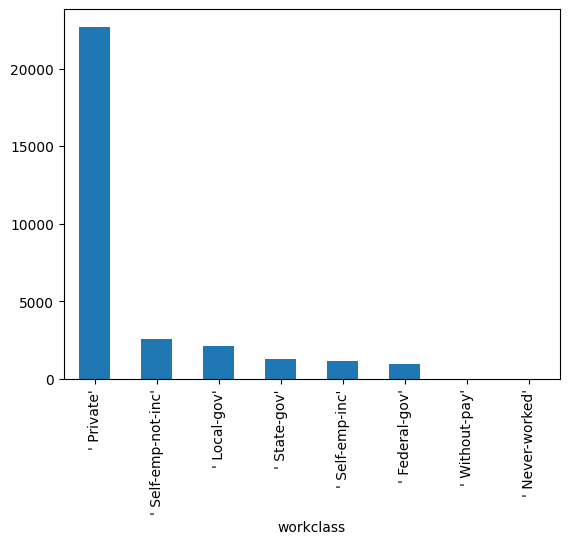

In [27]:
#Conocemos las variables categóricas

#Grafica de la variable workclass

data['workclass'].value_counts().plot(kind='bar')

<Axes: xlabel='education'>

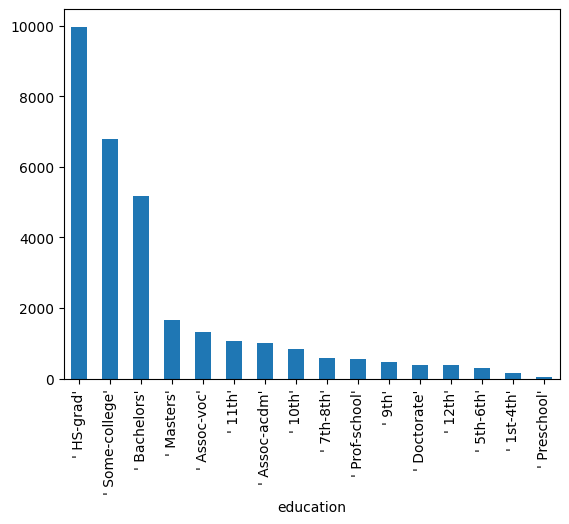

In [28]:
#Grafica de la variable education

data['education'].value_counts().plot(kind='bar')

<Axes: xlabel='marital-status'>

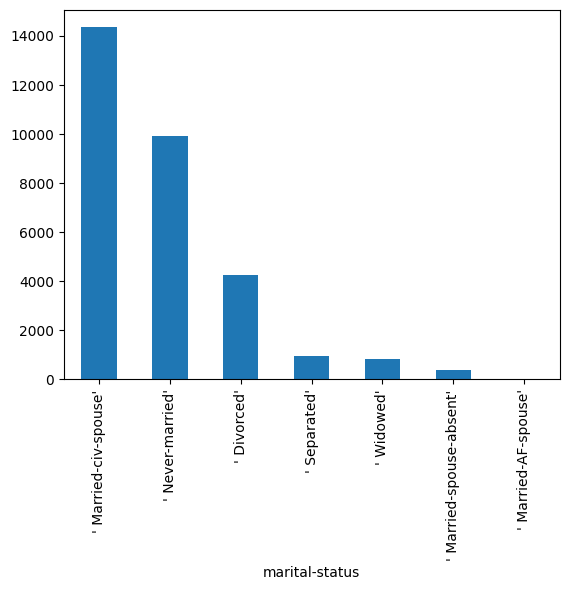

In [29]:
#Grafica de la variable marital-status

data['marital-status'].value_counts().plot(kind='bar')

<Axes: xlabel='occupation'>

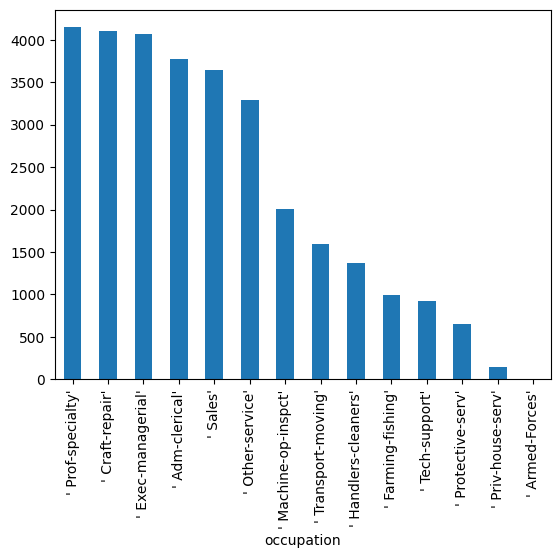

In [30]:
#Grafica de la variable occupation

data['occupation'].value_counts().plot(kind='bar')

<Axes: xlabel='sex'>

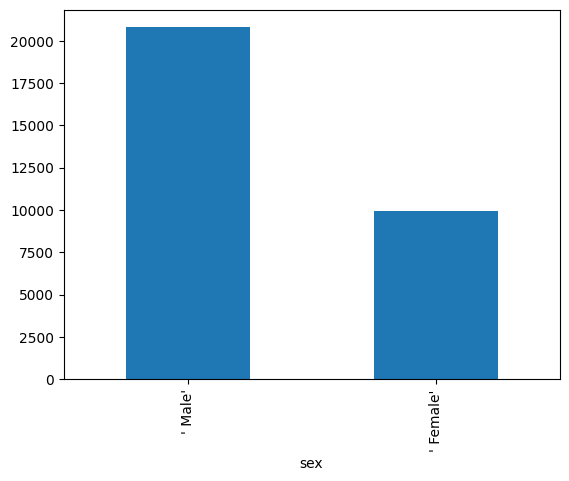

In [31]:
#Grafica de la variable sex

data['sex'].value_counts().plot(kind='bar')

<Axes: xlabel='income'>

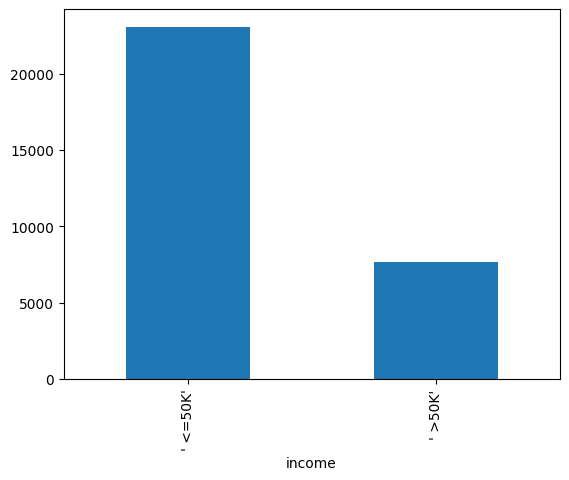

In [32]:
#Grafica de la variable income

data['income'].value_counts().plot(kind='bar')

## 2. Transformaciones:

In [33]:
#codificacion

#Dummies para variables con más de 2 categorías
data = pd.get_dummies(data, columns = categoricas_narias, drop_first=False, dtype = int)

#Dummies para variable con 2 categorías
data = pd.get_dummies(data, columns = categoricas_binarias, drop_first=True, dtype = int)

data.head()

,age,capital-gain,capital-loss,hours-per-week,workclass_' Federal-gov',workclass_' Local-gov',workclass_' Never-worked',workclass_' Private',workclass_' Self-emp-inc',workclass_' Self-emp-not-inc',...,occupation_' Machine-op-inspct',occupation_' Other-service',occupation_' Priv-house-serv',occupation_' Prof-specialty',occupation_' Protective-serv',occupation_' Sales',occupation_' Tech-support',occupation_' Transport-moving',sex_' Male',income_' >50K'
0,17,0,0,30,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,17,0,0,40,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,18,0,0,5,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,18,0,0,8,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
4,18,0,0,10,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


# 3. Correlaciones: relaciones lineales

* No se normaliza

In [34]:
# Correlaciones

correlaciones=data.corr()
correlaciones

,age,capital-gain,capital-loss,hours-per-week,workclass_' Federal-gov',workclass_' Local-gov',workclass_' Never-worked',workclass_' Private',workclass_' Self-emp-inc',workclass_' Self-emp-not-inc',...,occupation_' Machine-op-inspct',occupation_' Other-service',occupation_' Priv-house-serv',occupation_' Prof-specialty',occupation_' Protective-serv',occupation_' Sales',occupation_' Tech-support',occupation_' Transport-moving',sex_' Male',income_' >50K'
age,1.000000,0.080420,0.060463,0.102192,0.056824,0.068246,-0.020560,-0.210418,0.112132,0.149455,...,-0.014574,-0.092196,0.017481,0.061556,0.005758,-0.030380,-0.019059,0.031383,0.082028,0.242546
capital-gain,0.080420,1.000000,-0.032325,0.079560,-0.006529,-0.008135,-0.002227,-0.048569,0.097627,0.031251,...,-0.027366,-0.042277,-0.007691,0.085163,-0.007792,0.010483,-0.010175,-0.019223,0.047750,0.221882
capital-loss,0.060463,-0.032325,1.000000,0.053998,0.010351,0.013974,-0.003308,-0.036814,0.031710,0.020537,...,-0.017694,-0.043271,-0.011607,0.045791,-0.003823,0.008519,0.004253,-0.004277,0.047000,0.151483
hours-per-week,0.102192,0.079560,0.053998,1.000000,0.006483,0.000820,-0.015764,-0.095286,0.127488,0.087054,...,-0.004200,-0.180557,-0.046941,0.046684,0.023579,-0.005065,-0.022294,0.072465,0.230253,0.228611
workclass_' Federal-gov',0.056824,-0.006529,0.010351,0.006483,1.000000,-0.048556,-0.002711,-0.301944,-0.034866,-0.053924,...,-0.036802,-0.041083,-0.012537,0.024871,0.010046,-0.057845,0.042634,-0.020983,-0.001870,0.057095
workclass_' Local-gov',0.068246,-0.008135,0.013974,0.000820,-0.048556,1.000000,-0.004081,-0.454572,-0.052490,-0.081182,...,-0.065099,-0.013133,-0.018874,0.159729,0.233384,-0.096476,-0.019032,0.003615,-0.043756,0.028642
workclass_' Never-worked',-0.020560,-0.002227,-0.003308,-0.015764,-0.002711,-0.004081,1.000000,-0.025380,-0.002931,-0.004533,...,-0.003985,-0.005232,-0.001054,0.038216,-0.002218,-0.005543,-0.002664,-0.003535,0.001212,-0.008692
workclass_' Private',-0.210418,-0.048569,-0.036814,-0.095286,-0.301944,-0.454572,-0.025380,1.000000,-0.326411,-0.504830,...,0.130313,0.073270,0.041520,-0.162668,-0.149094,0.056280,0.021860,0.028808,-0.065794,-0.117848
workclass_' Self-emp-inc',0.112132,0.097627,0.031710,0.127488,-0.034866,-0.052490,-0.002931,-0.326411,1.000000,-0.058294,...,-0.042092,-0.052108,-0.013553,0.004771,-0.022470,0.085180,-0.031212,-0.024299,0.083966,0.138444
workclass_' Self-emp-not-inc',0.149455,0.031251,0.020537,0.087054,-0.053924,-0.081182,-0.004533,-0.504830,-0.058294,1.000000,...,-0.062035,-0.037235,-0.020961,0.010388,-0.039177,0.030365,-0.035038,-0.005363,0.106715,0.024959


In [35]:
# Identificamos el nombre de la variable dummie 'income' resultante tras el preprocesamiento para referenciarla correctamente en el análisis de correlación.

columnas_income = [col for col in data.columns if 'income' in col]
print(columnas_income)

["income_' >50K'"]


In [36]:
#Correlaciones con la variable de interés income

cor_variable_interes=correlaciones.loc["income_' >50K'"]
cor_variable_interes

,income_' >50K'
age,0.242546
capital-gain,0.221882
capital-loss,0.151483
hours-per-week,0.228611
workclass_' Federal-gov',0.057095
workclass_' Local-gov',0.028642
workclass_' Never-worked',-0.008692
workclass_' Private',-0.117848
workclass_' Self-emp-inc',0.138444
workclass_' Self-emp-not-inc',0.024959


# 4. Interpretación

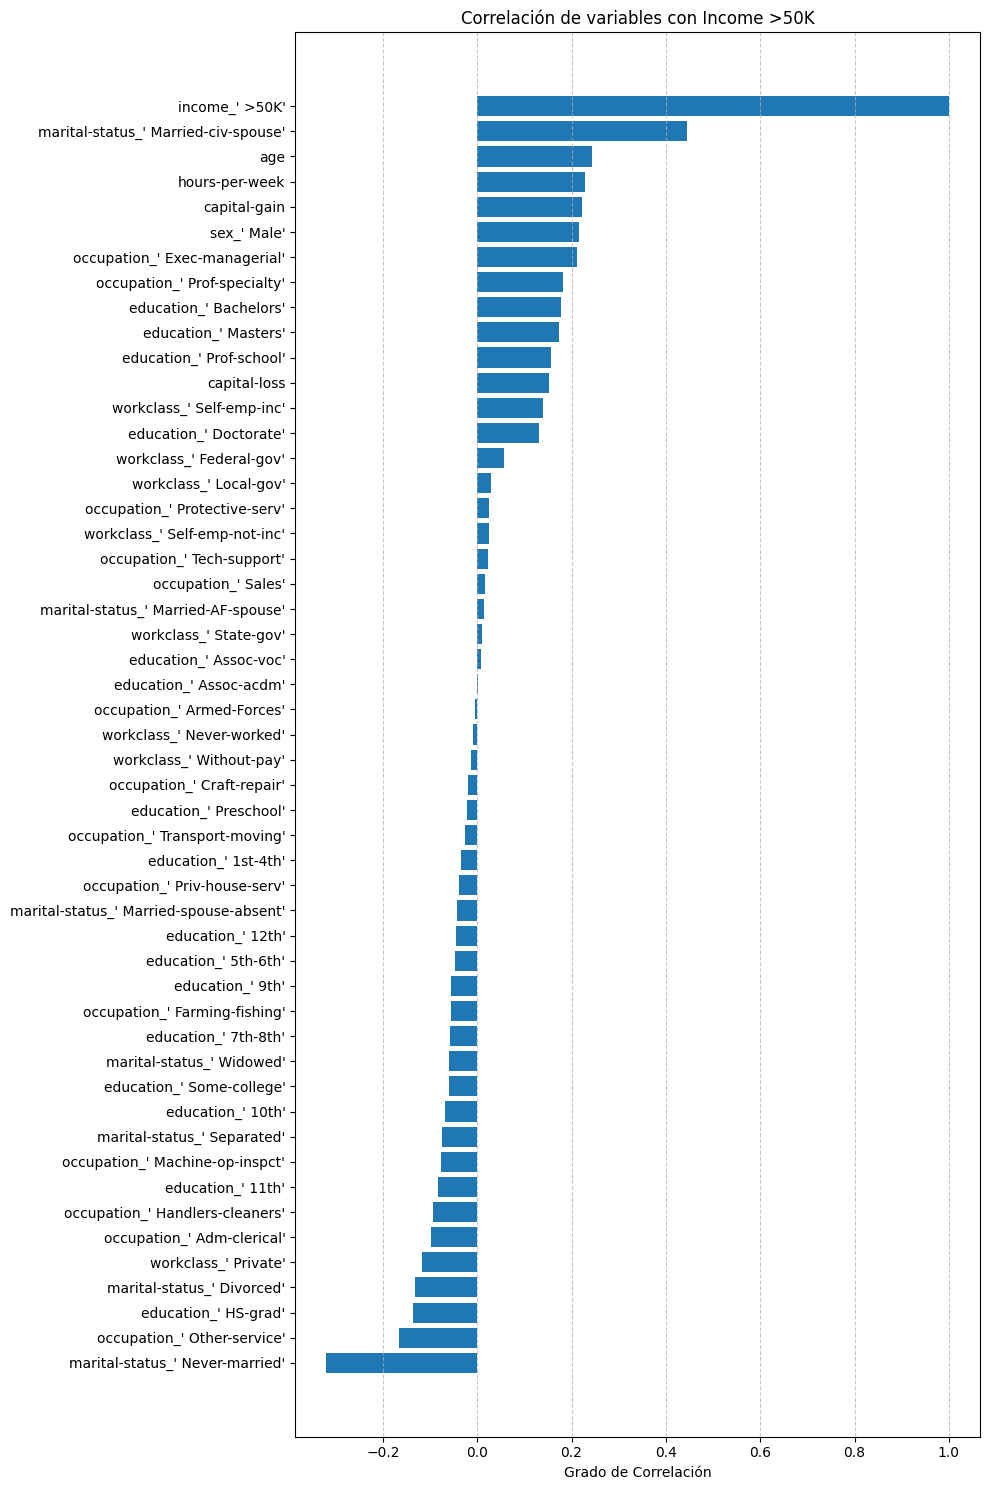

In [37]:
#Graficas de las correlaciones con la variable de interes "income_' >50K'"

# 1. Ordenamos la serie de correlaciones de menor a mayor
cor_ordenada = cor_variable_interes.sort_values(ascending=True)

# 2. Graficamos
plt.figure(figsize=(10, 15))
plt.barh(y = cor_ordenada.index, width = cor_ordenada)
plt.title("Correlación de variables con Income >50K")
plt.xlabel("Grado de Correlación")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()